<a href="https://colab.research.google.com/github/hosseinta2/RL/blob/main/deepQ_atari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import numpy as np
import collections
import typing as tt
import cv2

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim


AtariResetReturn = tuple[np.ndarray, dict[str, tt.Any]]
AtariStepReturn = tuple[np.ndarray, float, bool, bool, dict[str, tt.Any]]


class FireResetEnv(gym.Wrapper):
    """
    For Atari games like Breakout/Pong where the game only starts after FIRE.
    """

    def __init__(self, env: gym.Env) -> None:
        super().__init__(env)

        meanings = env.unwrapped.get_action_meanings()
        assert meanings[1] == "FIRE"
        assert len(meanings) >= 3

    def reset(self, **kwargs) -> AtariResetReturn:
        obs, info = self.env.reset(**kwargs)

        obs, _, terminated, truncated, _ = self.env.step(1)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)

        obs, _, terminated, truncated, _ = self.env.step(2)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)

        return obs, info


class MaxAndSkipEnv(gym.Wrapper):
    """
    Repeat the same action for `skip` frames and return max over last two frames.
    """

    def __init__(self, env: gym.Env, skip: int = 4) -> None:
        super().__init__(env)

        self._obs_buffer = np.zeros(
            (2, *env.observation_space.shape),
            dtype=env.observation_space.dtype
        )
        self._skip = skip

    def step(self, action: int) -> AtariStepReturn:
        total_reward = 0.0
        terminated = False
        truncated = False
        info = {}

        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            total_reward += float(reward)

            if i == self._skip - 2:
                self._obs_buffer[0] = obs

            if i == self._skip - 1:
                self._obs_buffer[1] = obs

            if terminated or truncated:
                break

        max_frame = self._obs_buffer.max(axis=0)

        return max_frame, total_reward, terminated, truncated, info


class WarpFrame(gym.ObservationWrapper):
    """
    Convert RGB frame to grayscale and resize to 84 x 84.
    """

    def __init__(self, env: gym.Env, width: int = 84, height: int = 84) -> None:
        super().__init__(env)

        self.width = width
        self.height = height

        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(self.height, self.width, 1),
            dtype=np.uint8,
        )

    def observation(self, frame: np.ndarray) -> np.ndarray:
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(
            frame,
            (self.width, self.height),
            interpolation=cv2.INTER_AREA
        )
        return frame[:, :, None]


class ImageToPyTorch(gym.ObservationWrapper):
    """
    Change image format from HWC to CHW.
    Example: 84 x 84 x 1 becomes 1 x 84 x 84.
    """

    def __init__(self, env: gym.Env) -> None:
        super().__init__(env)

        obs = self.observation_space
        assert isinstance(obs, spaces.Box)
        assert len(obs.shape) == 3

        new_shape = (obs.shape[-1], obs.shape[0], obs.shape[1])

        self.observation_space = spaces.Box(
            low=obs.low.min(),
            high=obs.high.max(),
            shape=new_shape,
            dtype=obs.dtype,
        )

    def observation(self, observation: np.ndarray) -> np.ndarray:
        return np.moveaxis(observation, 2, 0)


class BufferWrapper(gym.ObservationWrapper):
    """
    Stack the last n observations.
    For Atari DQN, usually n_steps=4.
    """

    def __init__(self, env: gym.Env, n_steps: int) -> None:
        super().__init__(env)

        self.buffer = collections.deque(maxlen=n_steps)

        obs = env.observation_space
        assert isinstance(obs, spaces.Box)

        self.observation_space = spaces.Box(
            low=np.repeat(obs.low, n_steps, axis=0),
            high=np.repeat(obs.high, n_steps, axis=0),
            dtype=obs.dtype,
        )

    def reset(
        self,
        *,
        seed: tt.Optional[int] = None,
        options: tt.Optional[dict[str, tt.Any]] = None
    ):
        obs, info = self.env.reset(seed=seed, options=options)

        for _ in range(self.buffer.maxlen):
            self.buffer.append(obs)

        return self.observation(obs), info

    def observation(self, observation: np.ndarray) -> np.ndarray:
        self.buffer.append(observation)
        return np.concatenate(self.buffer, axis=0)


def make_env(env_name: str, **kwargs) -> gym.Env:
    env = gym.make(env_name, **kwargs)

    env = MaxAndSkipEnv(env)

    if "FIRE" in env.unwrapped.get_action_meanings():
        env = FireResetEnv(env)

    env = WarpFrame(env)
    env = ImageToPyTorch(env)
    env = BufferWrapper(env, n_steps=4)

    return env



In [2]:
!pip install -q -U "gymnasium[atari,accept-rom-license]" ale-py opencv-python

In [3]:
import gymnasium as gym
import ale_py

gym.register_envs(ale_py)

#env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
env = make_env("PongNoFrameskip-v4")
obs, info = env.reset()
print(obs.shape)

obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print(obs.shape, reward, terminated, truncated)

(4, 84, 84)
(4, 84, 84) 0.0 False False


In [4]:
import torch
import torch.nn as nn
class CNN(nn.Module):
  def __init__(self,input_shape,n_actions):
     super().__init__()

     self.conv = nn.Sequential(nn.Conv2d(input_shape[0],32,kernel_size= 8, stride=4),
                               nn.ReLU(),
                               nn.Conv2d(32, 64, kernel_size=4, stride=2),
                               nn.ReLU(),
                               nn.Conv2d(64, 64, kernel_size=3, stride=1),
                               nn.ReLU(),
                               nn.Flatten(),
                               )
     size = self.conv(torch.zeros(1, *input_shape)).size()[-1]
     self.fc = nn.Sequential(nn.Linear(size,512),
                             nn.ReLU(),
                             nn.Linear(512,n_actions))
  def forward(self,x: torch.ByteTensor):
    x = x/255.0
    return self.fc(self.conv(x))

In [5]:
import gymnasium as gym
from dataclasses import dataclass
import argparse
import time
import numpy as np
import collections
import typing as tt
import torch
import torch.nn as nn
import torch.optim as optim

DEFAULT_ENV_NAME = "PongNoFrameskip-v4"
MEAN_REWARD_BOUND = 19

GAMMA = 0.99
BATCH_SIZE = 32
REPLAY_SIZE = 10000 # Buffer capacity

LEARNING_RATE = 1e-4 # Adam learning rate
SYNC_TARGET_FRAMES = 1000 # number of frames needed to sync the target and model weights
REPLAY_START_SIZE = 10000 # skipping this many initial frames during SGD to saturate the buffer

EPSILON_DECAY_LAST_FRAME = 150000
EPSILON_START = 1.0
EPSILON_FINAL = 0.01

State = np.ndarray
Action = int
BatchTensors = tt.Tuple[
    torch.ByteTensor,
    torch.LongTensor,
    torch.Tensor,
    torch.BoolTensor,
    torch.ByteTensor
]
@dataclass
class Experience:
  state: State
  action: Action
  reward: float
  done_trunc: bool
  next_state: State

class Buffer:
  def __init__(self,capacity):
     self.buffer = collections.deque(maxlen=capacity)
  def __len__(self):
    return len(self.buffer)
  def append(self,experience):
    self.buffer.append(experience)
  def sample(self, batch_size):
    indices = np.random.choice(len(self),batch_size,replace=False)
    return [self.buffer[idx] for idx in indices]

class Agent:
  def __init__(self, env, buffer):
    self.env = env
    self.buffer = buffer
    self.state,_ = env.reset()
    self.total_reward = 0.0
  def play(self, env, model, eps, device):
    if np.random.random() < eps:
      action = env.action_space.sample()
    else:
      state_v = torch.as_tensor(self.state, dtype=torch.float32, device=device).unsqueeze(0)
      with torch.no_grad():
          q_vals = model(state_v)
      action = int(torch.argmax(q_vals,dim=1).item())
    next_state,reward,is_done,is_truncated,_ = env.step(action)
    exp = Experience(state = self.state,
                       action = action,
                       reward = reward,
                       done_trunc = is_done or is_truncated,
                       next_state=next_state)
    self.buffer.append(exp)
    self.state = next_state
    self.total_reward += reward
    if is_done or is_truncated:
      self.state,_ = env.reset()
      episode_reward = self.total_reward
      self.total_reward = 0.0
      return episode_reward
    return None

  def batch_to_tensor(self,batch,device):
    states,actions,rewards,done,next_states = [],[],[],[],[]
    for b in batch:
      states.append(b.state)
      actions.append(b.action)
      rewards.append(b.reward)
      done.append(b.done_trunc)
      next_states.append(b.next_state)

    states_t = torch.as_tensor(np.asarray(states)).to(device)
    actions_t = torch.LongTensor(actions).to(device)
    rewards_t = torch.FloatTensor(rewards).to(device)
    dones_t = torch.BoolTensor(done).to(device)
    next_states_t = torch.as_tensor(np.asarray(next_states)).to(device)
    return states_t, actions_t, rewards_t, dones_t, next_states_t

  def loss_calculation(self,net,target_net,batch,device):
    states_t, actions_t, rewards_t, dones_t, next_states_t = self.batch_to_tensor(batch,device)
    outs = net(states_t).gather(1,actions_t.unsqueeze(-1)).squeeze(-1)
    with torch.no_grad():
        targets_out = torch.max(target_net(next_states_t),dim=-1).values
        targets_out[dones_t] = 0.0
        #targets_out = targets_out.detach()
        targets = rewards_t + GAMMA * targets_out
    los_f = nn.MSELoss()
    loss_val = los_f(outs, targets)
    return loss_val





In [6]:
device = torch.device("cuda")
net = CNN(env.observation_space.shape, env.action_space.n).to(device)
target_net = CNN(env.observation_space.shape, env.action_space.n).to(device)
target_net.load_state_dict(net.state_dict())
buffer = Buffer(REPLAY_SIZE)
agent = Agent(env, buffer)
epsilon = EPSILON_START
optimizer = optim.Adam(net.parameters(),lr=LEARNING_RATE)
total_rewards = []
frame_idx = 0
ts_frame = 0
ts = time.time()
total_rewards = []
while True:
  frame_idx += 1
  epsilon = max(EPSILON_FINAL, EPSILON_START - frame_idx /EPSILON_DECAY_LAST_FRAME)
  reward = agent.play(env,net,epsilon,device)
  if reward!=None:
    total_rewards.append(reward)
    speed = (frame_idx - ts_frame) / (time.time() - ts)
    ts_frame = frame_idx
    ts = time.time()
    m_reward = np.mean(total_rewards[-100:])
    if len(total_rewards)%5==0: # every 5 games played, display the results
        print(f"{frame_idx}       {len(total_rewards)} games, reward {m_reward:.3f}, "
              f"eps {epsilon:.2f}        {speed:.2f} f/s")
    if m_reward > MEAN_REWARD_BOUND:
      print("Solved in %d frames!" % frame_idx)
      break
  if len(buffer) < REPLAY_START_SIZE:
    continue
  if frame_idx % SYNC_TARGET_FRAMES == 0: #update the target net weights every SYNC_TARGET_FRAMES frames
    target_net.load_state_dict(net.state_dict())
  optimizer.zero_grad()
  batch = buffer.sample(BATCH_SIZE)
  loss_t = agent.loss_calculation(net,target_net,batch,device)
  loss_t.backward()
  optimizer.step()




4412       5 games, reward -20.800, eps 0.97        1181.37 f/s
8851       10 games, reward -20.700, eps 0.94        1161.76 f/s
13524       15 games, reward -20.600, eps 0.91        171.84 f/s
18072       20 games, reward -20.450, eps 0.88        174.26 f/s
22586       25 games, reward -20.400, eps 0.85        181.98 f/s
26765       30 games, reward -20.467, eps 0.82        167.26 f/s
31352       35 games, reward -20.429, eps 0.79        169.95 f/s
36297       40 games, reward -20.275, eps 0.76        187.86 f/s
41036       45 games, reward -20.178, eps 0.73        185.89 f/s
45524       50 games, reward -20.220, eps 0.70        183.96 f/s
50156       55 games, reward -20.236, eps 0.67        180.86 f/s
54825       60 games, reward -20.200, eps 0.63        165.04 f/s
59642       65 games, reward -20.200, eps 0.60        165.70 f/s
64754       70 games, reward -20.129, eps 0.57        176.17 f/s
70310       75 games, reward -20.080, eps 0.53        159.60 f/s
75978       80 games, rewa

KeyboardInterrupt: 

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# 1. Save current model
# --------------------
save_path = "/content/dqn_pong.pt"

checkpoint = {
    "model_state_dict": net.state_dict(),
    "target_model_state_dict": target_net.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "frame_idx": frame_idx,
    "epsilon": epsilon,
    "total_rewards": total_rewards,
    "env_name": DEFAULT_ENV_NAME,
    "gamma": GAMMA,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
}

torch.save(checkpoint, save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/dqn_pong.pt


In [8]:
from google.colab import files
files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

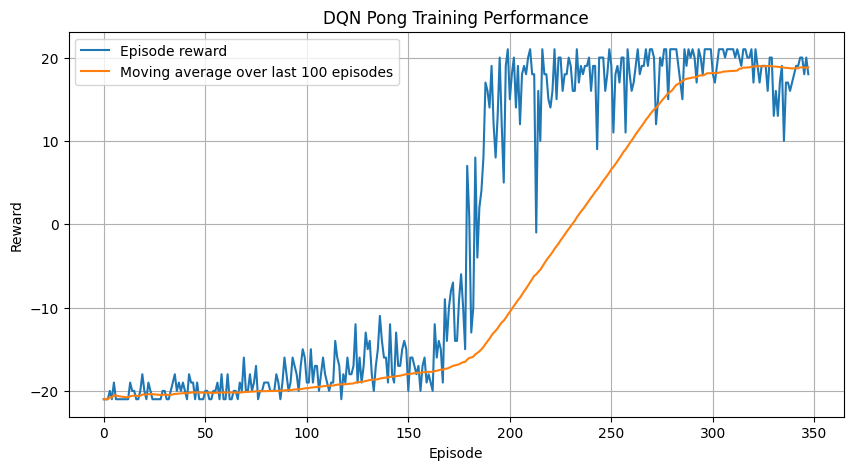

Number of episodes: 348
Last episode reward: 18.00
Mean reward over last 100 episodes: 18.82


In [9]:
# --------------------
# 2. Plot training reward
# --------------------
rewards = np.array(total_rewards, dtype=np.float32)

moving_avg = np.array([
    np.mean(rewards[max(0, i-99):i+1])
    for i in range(len(rewards))
])

plt.figure(figsize=(10, 5))
plt.plot(rewards, label="Episode reward")
plt.plot(moving_avg, label="Moving average over last 100 episodes")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Pong Training Performance")
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of episodes: {len(total_rewards)}")
print(f"Last episode reward: {total_rewards[-1]:.2f}")
print(f"Mean reward over last 100 episodes: {np.mean(total_rewards[-100:]):.2f}")

In [10]:
!pip install -q imageio imageio-ffmpeg

In [12]:
# For loading the weights
# --------------------
# Load saved DQN weights
# --------------------
import torch
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

load_path = "/content/dqn_pong.pt"

checkpoint = torch.load(
    load_path,
    map_location=device,
    weights_only=False
)

# Recover saved settings
DEFAULT_ENV_NAME = checkpoint.get("env_name", "PongNoFrameskip-v4")
GAMMA = checkpoint.get("gamma", GAMMA)
BATCH_SIZE = checkpoint.get("batch_size", BATCH_SIZE)
LEARNING_RATE = checkpoint.get("learning_rate", LEARNING_RATE)

# Recreate environment
env = make_env(DEFAULT_ENV_NAME)

# Recreate networks
net = CNN(env.observation_space.shape, env.action_space.n).to(device)

# Load weights
net.load_state_dict(checkpoint["model_state_dict"])

# Recreate optimizer and load optimizer state
optimizer = optim.Adam(net.parameters(), lr=LEARNING_RATE)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Move optimizer tensors to GPU/CPU correctly
for state in optimizer.state.values():
    for k, v in state.items():
        if torch.is_tensor(v):
            state[k] = v.to(device)

# Recover training variables
frame_idx = checkpoint.get("frame_idx", 0)
epsilon = checkpoint.get("epsilon", EPSILON_FINAL)
total_rewards = checkpoint.get("total_rewards", [])

net.eval()

print(f"Loaded model from: {load_path}")
print(f"Device: {device}")
print(f"Frame index: {frame_idx}")
print(f"Epsilon: {epsilon}")
print(f"Number of saved episodes: {len(total_rewards)}")

if len(total_rewards) > 0:
    print(f"Last reward: {total_rewards[-1]:.2f}")
    print(f"Mean reward over last 100 episodes: {np.mean(total_rewards[-100:]):.2f}")

Loaded model from: /content/dqn_pong.pt
Device: cuda
Frame index: 587182
Epsilon: 0.01
Number of saved episodes: 348
Last reward: 18.00
Mean reward over last 100 episodes: 18.82


In [14]:
# displaying the model's performance

import torch
import numpy as np
import imageio
from IPython.display import Video, display

def record_dqn_video(
    model,
    env_name=DEFAULT_ENV_NAME,
    video_path="/content/dqn_pong_eval.mp4",
    max_steps=10000,
    device=device,
):
    # Important: render_mode="rgb_array" lets us collect frames
    eval_env = make_env(env_name, render_mode="rgb_array")

    state, _ = eval_env.reset()
    frames = []

    # First rendered frame
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    total_reward = 0.0
    done = False
    step = 0

    model.eval()

    while not done and step < max_steps:
        state_v = torch.as_tensor(
            state, dtype=torch.float32, device=device
        ).unsqueeze(0)

        with torch.no_grad():
            q_vals = model(state_v)

        # Greedy action: epsilon = 0
        action = int(torch.argmax(q_vals, dim=1).item())

        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
        step += 1

        frame = eval_env.render()
        if frame is not None:
            frames.append(frame)

    eval_env.close()
    model.train()

    imageio.mimsave(video_path, frames, fps=30)

    print(f"Evaluation reward: {total_reward}")
    print(f"Number of frames in video: {len(frames)}")
    print(f"Video saved to: {video_path}")

    return video_path, total_reward


video_path, eval_reward = record_dqn_video(net)

display(Video(video_path, embed=True))

Evaluation reward: 21.0
Number of frames in video: 1636
Video saved to: /content/dqn_pong_eval.mp4
